# Model LDA w ramach ryzyka operacyjnego

# Antoni Kois

### Pytania teoretyczne:

#### Wyjaśnić jakie ryzyko mierzy ryzyko operacyjne.

Ad: 

#### Na podstawie treści z wykładu (oraz ew. innych wiarygodnych źródeł) wyjaśnić, jak obecnie wyznacza się ryzyko operacyjne w bankach. Dlaczego metoda rozkładu strat (LDA) nie jest uważana za optymalną? 

Ad: 

### Zadanie praktyczne:
Do wykonania poniższego zadania należy wykorzystać plik z katalogu dane, który zawiera dane dotyczące wysokości strat brutto dla wybranego okresu oraz kategorii ryzyka. Stosując AMA (a dokładniej model LDA), wykorzystując dwie dowolne linie biznesowe (w pliku jest ich siedem - do analizy należy wybrać dowolne dwie) należy wyznaczyć roczny 99,9% OpVaR oraz OpES dla danego banku.

W tym celu:
- Przeprowadzić krótką EDA pokazującą częstotliwość oraz dotkliwość strat operacyjnych w ramach wybranych linii biznesowych. 
- Za pomocą logiki lub/oraz dostępnych testów zgodności dopasować możliwie najlepszy rozkład liczby zdarzeń operacyjnych oraz rozkład ich dotkliwości. Ustalić parametry wybranych rozkładów. Tam, gdzie testy nie pozwalają na sensowną weryfikację założeń o rozkładzie, dobrać rozkład lognormalny.
- Znając rozkład częstości i rozkład wartości strat (ich parametry) wygenerować 10000 scenariuszy i wyznaczyć symulacyjny rozkład strat.
- Na podstawie wygenerowanych danych wyznaczyć 99,9% OpVaR oraz OpES.

# Zadanie prkatyczne

Wybieramy dwie linie biznesowe, będą to:

- Internal_Fr
- External_Fr

Aby lepiej zrozumieć czym te dane są, na początku przedstawię znaczenie tych linii.
Zgodnie z klasyfikacją regulacyjną (np. standardami z Bazylei), nadużycia dzieli się na dwie główne kategorie:
- **Internal Fraud** (Oszustwo wewnętrzne): Sytuacje, w których straty wynikają z celowych działań pracowników banku, a dokłądniej to w które zaangażowana jest co najmniej jedna osoba z wewnątrz. Przykładami takich wewnętrznych oszustw są:
	- pracownik świadomie ignoruje procedury, aby przyznać kredyt osobie bez zdolności kredytowej
	- kradzież gotówki przez kasjera
	- księgowanie fikcyjnych transakcji przez maklera
	- nadużycia uprawnień
	- łapówkarstwo
	- wykorzystywanie informacji poufnych (insider trading)
- **External Fraud** (Oszustwo zewnętrzne): Sytuacje, w których straty powodują osoby trzecie. Przykładami takich działań są:
	- ataki hakerskie (wyłudzenia z kont)
	- kradzież tożsamości klienta
	- fałszowanie czeków lub dokumentów kredytowych
	- napady na bankomat/oddział
	- skimming (kopiowanie kart płatniczych)

Przeważnie tych oszustw zewnętrznych powinno być więcej niż wewnętrznych, ale jak już zdążyłem w dalszej części pracy zauważyć, w tym przypadku jest zupełnie na odwrót. Ilość oszust wewnętrznych jest bardzo duża i przewyższa sporo oszustwa zewnętrzna. Może to wskazywać na mocny problem z personelem firmy, który mocno nad używa swoją władzę i pozwolenia.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RNG = np.random.default_rng(42)
LINES = ["Internal_Fr", "External_Fr"]

df = pd.read_csv("plik8.csv", index_col=0)
df = df[df["linia"].isin(LINES)].reset_index(drop=True)

print(f"Liczba obserwacji: {len(df)}")
print(f"Zakres lat: {df['rok'].min()}–{df['rok'].max()} (lat: {df['rok'].nunique()})")
print(f"Linie biznesowe: {df['linia'].unique().tolist()}")
df.head()


Liczba obserwacji: 4311
Zakres lat: 1989–2023 (lat: 35)
Linie biznesowe: ['External_Fr', 'Internal_Fr']


,rok,strata,linia
0,1989,"1,602.3600",External_Fr
1,1989,"13,329.4000",External_Fr
2,1989,"4,160.8100",External_Fr
3,1989,"1,802.6400",External_Fr
4,1989,998.0900,External_Fr


## EDA — częstość i dotkliwość strat

Dla każdej linii budujemy:

- szereg częstości (liczba zdarzeń w roku), stąd dopasujemy rozkład liczby zdarzeń,
- szereg dotkliwości (kwoty strat), stąd dopasujemy rozkład wartości strat.

Dane, które posiadamy są z lat 1989-2023, tak więc jest to dość szeroki zakres i hisotria danych.

In [10]:
# Szereg częstości, liczba zdarzeń w roku per linia
freq = {L: df[df["linia"] == L].groupby("rok").size() for L in LINES}

print("Częstość zdarzeń (zliczenia/rok):")
# Tworzę DataFrame z describe i ręcznie dopisuje wariancję oraz relację var/mean
stats_freq = {}
for L in LINES:
    desc = freq[L].describe()
    desc['var'] = freq[L].var()          # Obliczam wariancję
    desc['var/mean'] = desc['var'] / desc['mean'] # Relacja kluczowa dla wyboru rozkładu
    stats_freq[L] = desc

print(pd.DataFrame(stats_freq).round(2))

print("\nDotkliwość strat:")
print(df.groupby("linia")["strata"].describe().round(2))

Częstość zdarzeń (zliczenia/rok):
          Internal_Fr  External_Fr
count         35.0000      35.0000
mean         115.6300       7.5400
std            7.2500       1.8200
min          101.0000       4.0000
25%          111.0000       6.0000
50%          116.0000       8.0000
75%          120.5000       9.0000
max          135.0000      11.0000
var           52.5900       3.3100
var/mean       0.4500       0.4400

Dotkliwość strat:
                 count       mean        std     min        25%        50%  \
linia                                                                        
External_Fr   264.0000 4,000.0000 3,988.4900 11.6700 1,210.8200 2,701.6600   
Internal_Fr 4,047.0000 4,000.0100 3,984.8000 10.0000 1,190.6600 2,763.4600   

                   75%         max  
linia                               
External_Fr 5,576.7600 28,025.8700  
Internal_Fr 5,549.0900 31,205.2900  


#### Częstość

Jak ze statystyk możemy zauważyć, średnia zdarzeń dla wewnętrznych oszustw jest sporo większa od zewnętrznych (115,63 vs 35). Jest to dość zaskakujące odkrycie, ponieważ spodziewalibyśmy się, że to zewnętrzne oszustwa powinny mieć większą częstotliwość niż wewnętrzne. Może to świadczyć o problemie wewnątrz firmy i zarządzania personelem.
Widzimy też już nie było roku aby ilość oszust wewnętrznych nie spadła do poniżej 100, czyli można powiedzieć, że średnio nie było miesiąca, aby było mniej niż osiem oszustw wewnętrznych.

#### Dotkliwość

Widzimy jednak iż statystyki dla dotkliwości są bardzo podobne, a dokładniej to ich rozkłady. Mimo że dla tych oszustw wewnętrznych rekordów jest ich kilka razy więcej, to widzimy że mają one bardzo zbliżoną średnio odchylenie oraz poszczególne kwartyle. Podejrzewam, że dane zostały wygenerowane dlatego widzimy takie podobieństwo.

#### Oba

Dla obu miar odchylenie standardowe jest relatywnie male, co oznacza, ze liczba oszustw w każdym roku jest dość przewidywalna. W obu liniach wariancja jest znacznie mniejsza niz srednia (wspolczynnik wynosi ok. 0.45). Standardowy rozklad Poissona zaklada, ze wariancja jest rowna sredniej. U nas wariancja jest mniejsza. Dodatkowo uzasadnia to wybor rozkladu Dwumianowego, ktory lepiej pasuje do takich danych niz typowy rozklad Poissona.

W obu liniach srednia (~4000) jest znacznie wyzsza niz mediana (~2700). To typowe dla strat operacyjnych, mamy mase malych strat i kilka bardzo duzych, ktore podnosza srednia wartosc. Najwieksze straty (~28-31 tysiecy) są ponad 10-krotnie wieksze niz mediana. To sugeruje, ze rozklad ma tzw. gruby ogon, co musimy uwzglednic przy dopasowaniu modeli.

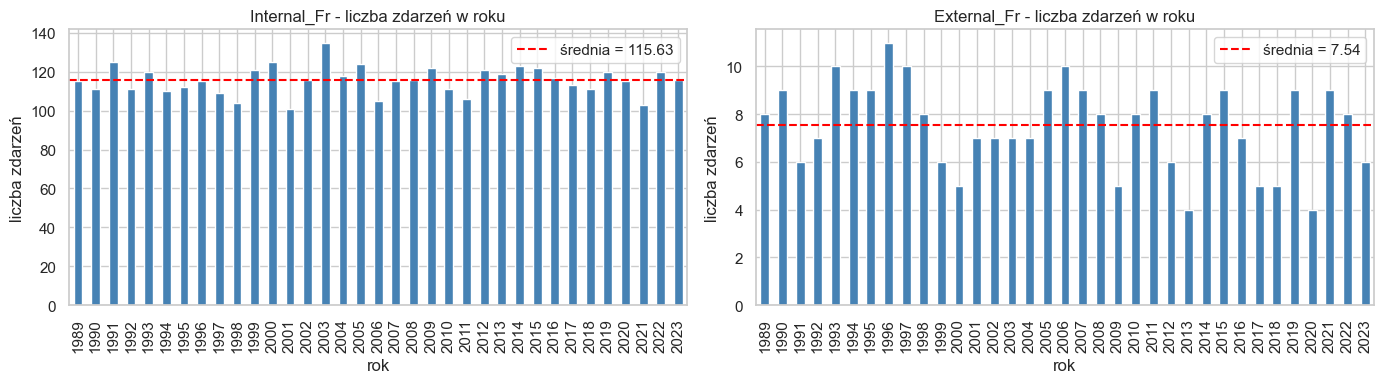

In [11]:
# Wizualizacja częstości
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, L in zip(axes, LINES):
    freq[L].plot(kind="bar", ax=ax, color="steelblue")
    ax.axhline(freq[L].mean(), color="red", linestyle="--",
               label=f"średnia = {freq[L].mean():.2f}")
    ax.set_title(f"{L} - liczba zdarzeń w roku")
    ax.set_xlabel("rok"); ax.set_ylabel("liczba zdarzeń")
    ax.legend()
plt.tight_layout(); plt.show()


Tak jak we wcześniejszej analizie zauważyliśmy, częstotliwości są dość ustabilizowane, jednak widać że dużo bardziej są one ustabilizowane w przypadku oszust wewnętrznych niż zewnętrznych. Może to też być też spowodowane tym, że po prostu ilość oszust zewnętrznych jest dużo mniej przez co nasza próbka danych jest mniejsza, a różnica 2-3 oszust już rzuca się w oczy bo jest relatywnie większa procentowo.

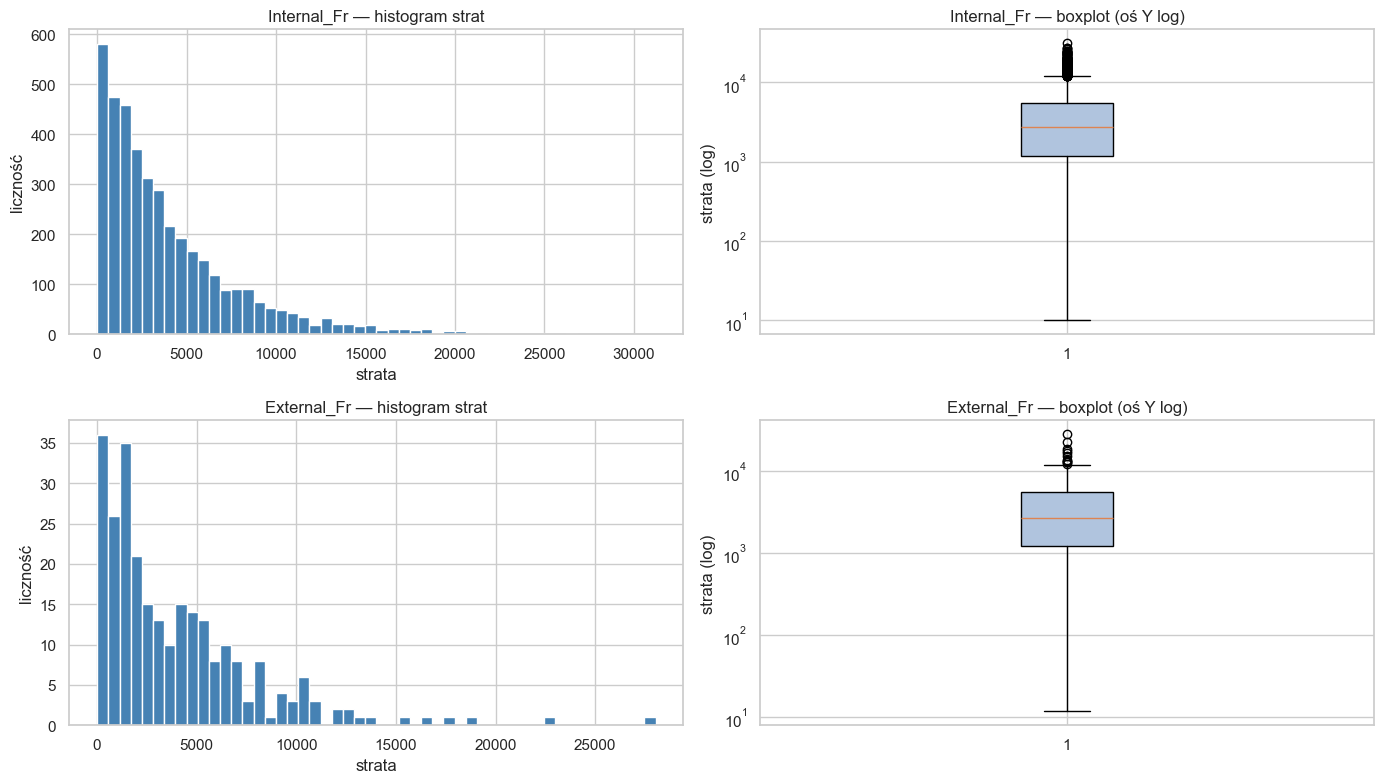

In [12]:
# Wizualizacja dotkliwości
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, L in enumerate(LINES):
    s = df.loc[df["linia"] == L, "strata"]
    axes[row, 0].hist(s, bins=50, color="steelblue", edgecolor="white")
    axes[row, 0].set_title(f"{L} — histogram strat")
    axes[row, 0].set_xlabel("strata"); axes[row, 0].set_ylabel("liczność")

    axes[row, 1].boxplot(s, vert=True, patch_artist=True,
                         boxprops=dict(facecolor="lightsteelblue"))
    axes[row, 1].set_yscale("log")
    axes[row, 1].set_title(f"{L} — boxplot (oś Y log)")
    axes[row, 1].set_ylabel("strata (log)")
plt.tight_layout(); plt.show()

# print("Statystyki opisowe dotkliwości:")
# df.groupby("linia")["strata"].describe()

Widzimy iż w obu przypadkach mamy wartości odstające, jest ich dość sporo. Także widzimy że faktycznie potwierdza nam się wcześniejsze podejrzenie o "grubych ogonach" w naszych rozkładach. Jak też można zauważyć najwięcej jest naj mniejszych strat a im one są większe tym rzadsze.

## Dopasowanie rozkładu częstości

Patrzymy na relację średniej do wariancji:
- Var ≈ E -> Poisson
- Var > E -> NegBin (overdispersion)
- Var < E -> Binomial (underdispersion)

Z wcześniejszej analizy EDA już wyciągnęliśmy te dane i są one następujące:

Internal_Fr:
E(N) = 115.63
Var(N) = 52.59
**Var/E = 0.45**

External_Fr:
E(N) = 7.54
Var(N) = 3.31
**Var/E = 0.44**

In [13]:
import pandas as pd
import numpy as np
from scipy import stats

def gof_summary(data, distributions):
    """Imitacja R-owego gofstat() dla listy rozkładów."""
    rows = []
    n = len(data)
    
    for name, dist_type in distributions.items():
        # Dopasowanie parametrów (MLE)
        params = dist_type.fit(data)
        arg = params[:-2]
        loc = params[-2]
        scale = params[-1]
        
        # Statystyki Goodness-of-Fit
        # 1. Kolmogorov-Smirnov
        ks_stat, ks_p = stats.kstest(data, name, args=params)
        
        # 2. Log-Likelihood (do AIC/BIC)
        log_lik = np.sum(dist_type.logpdf(data, *arg, loc=loc, scale=scale))
        k = len(params) # liczba parametrów
        aic = 2*k - 2*log_lik
        bic = k*np.log(n) - 2*log_lik
        
        rows.append({
            "Rozkład": name,
            "KS statistic": round(ks_stat, 4),
            "KS p-value": round(ks_p, 4),
            "AIC": round(aic, 2),
            "BIC": round(bic, 2),
            "Status (alpha=0.05)": "Nieodrzucony" if ks_p > 0.05 else "Odrzucony"
        })
    
    return pd.DataFrame(rows).set_index("Rozkład")


In [17]:
results_compare = []

for L in LINES:
    s = freq[L].values
    n = len(s)
    mu = s.mean()
    var = s.var(ddof=1)
    
    # Przygotowanie binów (wspólne dla obu testów)
    bins = np.histogram_bin_edges(s, bins='sturges')
    observed, _ = np.histogram(s, bins=bins)

    # --- TEST 1: POISSON ---
    p_probs = np.diff(stats.poisson.cdf(bins, mu))
    p_exp = p_probs * (n / p_probs.sum())
    _, p_val_poisson = stats.chisquare(observed, p_exp, ddof=1)

    # --- TEST 2: BINOMIAL (bo Var < E) ---
    # Parametry rozkładu dwumianowego z metody momentów
    prob_succ = 1 - (var / mu)
    n_trials = int(round(mu / prob_succ))
    
    b_probs = np.diff(stats.binom.cdf(bins, n_trials, prob_succ))
    b_exp = b_probs * (n / b_probs.sum())
    _, p_val_binom = stats.chisquare(observed, b_exp, ddof=2) # ddof=2 bo n i p estymowane

    results_compare.append({
        "Linia": L,
        "Poisson (p-val)": round(p_val_poisson, 4),
        "Binomial (p-val)": round(p_val_binom, 4),
        "Werdykt": "Binomial" if p_val_binom > p_val_poisson else "Poisson",
        "Uzasadnienie": f"Var/E = {var/mu:.2f} (Underdispersion)"
    })

df_compare = pd.DataFrame(results_compare)
print("Porównanie dopasowania częstości (Poisson vs Binomial):")
display(df_compare)


Porównanie dopasowania częstości (Poisson vs Binomial):


,Linia,Poisson (p-val),Binomial (p-val),Werdykt,Uzasadnienie
0,Internal_Fr,0.1385,0.1521,Binomial,Var/E = 0.45 (Underdispersion)
1,External_Fr,0.0529,0.0000,Poisson,Var/E = 0.44 (Underdispersion)


In [16]:
# Słownik rozkładów do przetestowania
dist_to_test = {
    "weibull_min": stats.weibull_min,
    "lognorm": stats.lognorm,
    "gamma": stats.gamma,
    "expon": stats.expon
}

for L in LINES:
    print(f"\nAnaliza dotkliwości dla linii: {L}")
    data_sev = df[df["linia"] == L]["strata"].values
    
    # Wywołanie naszej funkcji "gofstat"
    summary = gof_summary(data_sev, dist_to_test)
    display(summary)



Analiza dotkliwości dla linii: Internal_Fr


,KS statistic,KS p-value,AIC,BIC,Status (alpha=0.05)
Rozkład,,,,,
weibull_min,0.0125,0.5481,"75,204.3100","75,223.2300",Nieodrzucony
lognorm,0.0346,0.0001,"75,516.0500","75,534.9600",Odrzucony
gamma,0.0121,0.5854,"75,193.3500","75,212.2700",Nieodrzucony
expon,0.0088,0.9085,"75,209.8000","75,222.4100",Nieodrzucony



Analiza dotkliwości dla linii: External_Fr


,KS statistic,KS p-value,AIC,BIC,Status (alpha=0.05)
Rozkład,,,,,
weibull_min,0.0488,0.5391,inf,inf,Nieodrzucony
lognorm,0.0760,0.0898,"4,937.7400","4,948.4700",Nieodrzucony
gamma,0.9921,0.0000,"1,021,150.0400","1,021,160.7700",Odrzucony
expon,0.0440,0.6707,"4,909.7200","4,916.8700",Nieodrzucony


In [5]:
def chi2_test(observed, expected_pmf, n_params):
    """Prosty test chi-squared: agregujemy biny aby oczekiwane >= 5."""
    n = observed.sum()
    expected = expected_pmf * n
    # łącz biny od końca, aby oczekiwane >= 5
    obs_m, exp_m = [], []
    co = ce = 0
    for o, e in zip(observed[::-1], expected[::-1]):
        co += o; ce += e
        if ce >= 5:
            obs_m.append(co); exp_m.append(ce); co = ce = 0
    if ce > 0 and obs_m:
        obs_m[-1] += co; exp_m[-1] += ce
    obs_m, exp_m = np.array(obs_m[::-1]), np.array(exp_m[::-1])
    exp_m = exp_m * obs_m.sum() / exp_m.sum()  # normalizacja
    chi2 = ((obs_m - exp_m) ** 2 / exp_m).sum()
    dof = max(1, len(obs_m) - 1 - n_params)
    p = 1 - stats.chi2.cdf(chi2, dof)
    return chi2, p


frequency_dist = {}
for L in LINES:
    s = freq[L].values
    mean, var = s.mean(), s.var(ddof=1)
    print(f"\n{L}:  E(N)={mean:.2f}, Var(N)={var:.2f}, Var/E={var/mean:.2f}")

    obs = np.bincount(s)
    k_max = len(obs) + 30  # bufor na ogon

    # Poisson
    pois = stats.poisson(mu=mean)
    pmf_p = np.array([pois.pmf(k) for k in range(k_max)])
    chi2_p, p_p = chi2_test(np.pad(obs, (0, k_max - len(obs))), pmf_p, n_params=1)
    print(f"  Poisson(λ={mean:.2f})  → χ²={chi2_p:.2f}, p={p_p:.4f}")

    # Alternatywa
    if var > mean:
        # NegBin: p = mean/var, n = mean²/(var-mean)
        p_nb, n_nb = mean / var, mean ** 2 / (var - mean)
        alt = stats.nbinom(n=n_nb, p=p_nb)
        alt_name, alt_str = "nbinom", f"NegBin(n={n_nb:.2f}, p={p_nb:.2f})"
    else:
        # Binomial: p = 1 - var/mean, n = mean/p
        p_bn = 1 - var / mean
        n_bn = int(round(mean / p_bn))
        alt = stats.binom(n=n_bn, p=p_bn)
        alt_name, alt_str = "binom", f"Binomial(n={n_bn}, p={p_bn:.2f})"
    pmf_a = np.array([alt.pmf(k) for k in range(k_max)])
    chi2_a, p_a = chi2_test(np.pad(obs, (0, k_max - len(obs))), pmf_a, n_params=2)
    print(f"  {alt_str}  → χ²={chi2_a:.2f}, p={p_a:.4f}")

    # Wybór: wyższe p-value
    if p_p >= p_a:
        frequency_dist[L] = ("poisson", pois)
        print(f"  → wybieramy Poisson")
    else:
        frequency_dist[L] = (alt_name, alt)
        print(f"  → wybieramy {alt_name}")



Internal_Fr:  E(N)=115.63, Var(N)=52.59, Var/E=0.45
  Poisson(λ=115.63)  → χ²=6.51, p=0.1642
  Binomial(n=212, p=0.55)  → χ²=1.16, p=0.7636
  → wybieramy binom

External_Fr:  E(N)=7.54, Var(N)=3.31, Var/E=0.44
  Poisson(λ=7.54)  → χ²=7.12, p=0.0285
  Binomial(n=13, p=0.56)  → χ²=3.13, p=0.2092
  → wybieramy binom


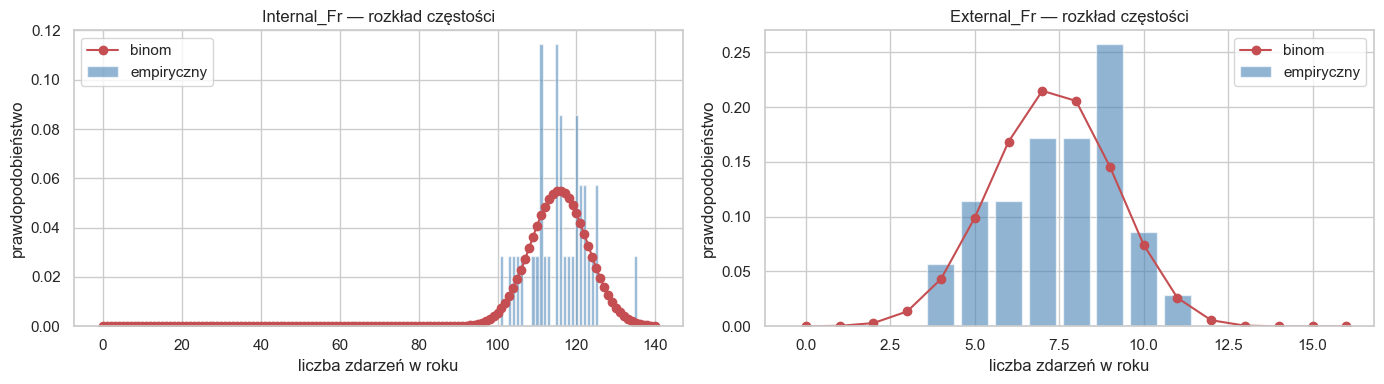

In [6]:
# Porównanie obserwowanego rozkładu częstości z dopasowanym
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, L in zip(axes, LINES):
    s = freq[L].values
    name, frozen = frequency_dist[L]
    counts = np.bincount(s)
    k_range = np.arange(0, len(counts) + 5)
    ax.bar(np.arange(len(counts)), counts / counts.sum(), alpha=0.6, color="steelblue", label="empiryczny")
    ax.plot(k_range, frozen.pmf(k_range), "ro-", label=name)
    ax.set_title(f"{L} — rozkład częstości")
    ax.set_xlabel("liczba zdarzeń w roku"); ax.set_ylabel("prawdopodobieństwo")
    ax.legend()
plt.tight_layout(); plt.show()


## Dopasowanie rozkładu dotkliwości

Dopasowujemy 4 kandydatów: lognormal, Weibull, gamma, exponential. Dla każdego liczymy test KS i AIC. Wybieramy rozkład nieodrzucony przez test KS o najniższym AIC (fallback: lognormal jeśli wszystkie odrzucone).

In [7]:
CANDIDATES = {
    "lognorm":     stats.lognorm,
    "weibull_min": stats.weibull_min,
    "gamma":       stats.gamma,
    "expon":       stats.expon,
}

severity_results = {}  # tabela wyników per linia
fitted_per_line = {}   # zapamiętane fits

for L in LINES:
    s = df.loc[df["linia"] == L, "strata"].values
    rows = []
    fits = {}
    for name, dist in CANDIDATES.items():
        params = dist.fit(s, floc=0)            # MLE z loc=0
        ll = dist.logpdf(s, *params).sum()
        k = len(params) - 1                      # liczba wolnych param.
        aic = -2 * ll + 2 * k
        ks_stat, ks_p = stats.kstest(s, dist.cdf, args=params)
        rows.append({"dist": name, "AIC": aic, "KS_stat": ks_stat, "KS_p": ks_p})
        fits[name] = (params, dist)
    tab = pd.DataFrame(rows).set_index("dist").round(4)
    severity_results[L] = tab
    fitted_per_line[L] = fits
    print(f"\n{L} (n={len(s)}):")
    print(tab)



Internal_Fr (n=4047):
                    AIC  KS_stat   KS_p
dist                                   
lognorm     75,901.9496   0.0711 0.0000
weibull_min 75,229.8283   0.0085 0.9279
gamma       75,229.6899   0.0084 0.9366
expon       75,228.0608   0.0100 0.8051

External_Fr (n=264):
                   AIC  KS_stat   KS_p
dist                                  
lognorm     4,966.5957   0.0845 0.0435
weibull_min 4,911.2293   0.0451 0.6383
gamma       4,911.1614   0.0454 0.6320
expon       4,909.2582   0.0439 0.6713


In [8]:
# Wybór: nieodrzucone przez KS (p > 0.05) → min AIC; fallback lognormal
severity_dist = {}
for L in LINES:
    tab = severity_results[L]
    not_rejected = tab[tab["KS_p"] > 0.05]
    if len(not_rejected) > 0:
        winner = not_rejected["AIC"].idxmin()
    else:
        winner = "lognorm"  # fallback z polecenia
    params, dist = fitted_per_line[L][winner]
    severity_dist[L] = (winner, dist(*params))
    print(f"{L}: {winner}, parametry = {params}")


Internal_Fr: expon, parametry = (0.0, 4000.011368915246)
External_Fr: expon, parametry = (0.0, 4000.000075757576)


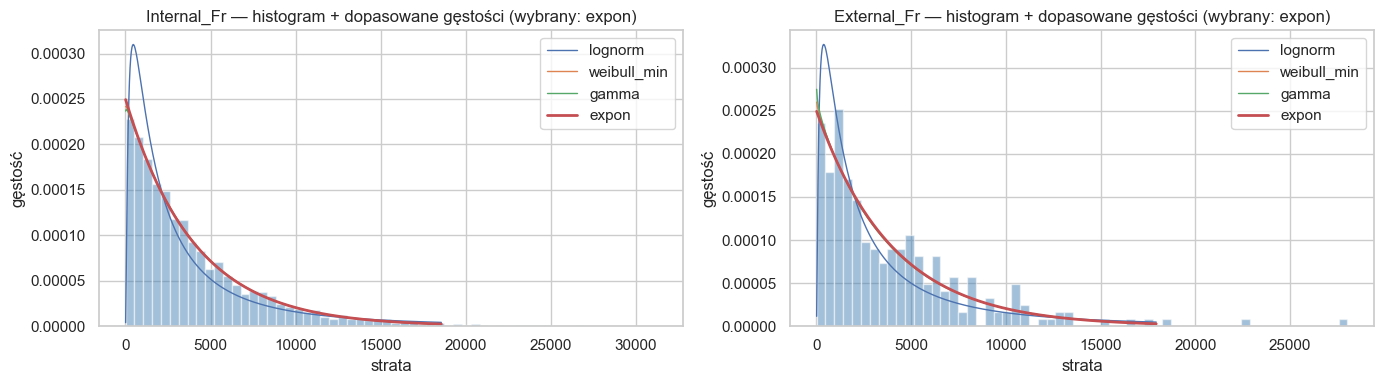

In [9]:
# Histogram strat + dopasowane gęstości (4 kandydaci)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, L in zip(axes, LINES):
    s = df.loc[df["linia"] == L, "strata"].values
    win_name, _ = severity_dist[L]
    ax.hist(s, bins=60, density=True, alpha=0.5, color="steelblue")
    x = np.linspace(s.min() + 1, np.quantile(s, 0.99), 500)
    for name, (params, dist) in fitted_per_line[L].items():
        ax.plot(x, dist.pdf(x, *params), label=name, lw=2 if name == win_name else 1)
    ax.set_title(f"{L} — histogram + dopasowane gęstości (wybrany: {win_name})")
    ax.set_xlabel("strata"); ax.set_ylabel("gęstość"); ax.legend()
plt.tight_layout(); plt.show()


## Symulacja Monte Carlo (10 000 scenariuszy)

Dla każdego z 10 000 scenariuszy (= roku) i dla każdej linii: losujemy N z rozkładu częstości, potem N strat z rozkładu dotkliwości i sumujemy. Strata banku = suma strat z obu linii.

In [10]:
N_SIM = 10_000
np.random.seed(42)

losses_per_line = {L: np.zeros(N_SIM) for L in LINES}

for L in LINES:
    _, freq_frozen = frequency_dist[L]
    _, sev_frozen = severity_dist[L]
    for i in range(N_SIM):
        n = freq_frozen.rvs()                          # liczba zdarzeń w roku
        if n > 0:
            losses_per_line[L][i] = sev_frozen.rvs(size=n).sum()  # suma strat

losses_total = losses_per_line[LINES[0]] + losses_per_line[LINES[1]]

for L in LINES:
    print(f"{L}: średnia roczna strata (sym.) = {losses_per_line[L].mean():,.2f}")
print(f"Suma rocznych strat banku — średnia = {losses_total.mean():,.2f}, max = {losses_total.max():,.2f}")


Internal_Fr: średnia roczna strata (sym.) = 463,222.50
External_Fr: średnia roczna strata (sym.) = 29,036.80
Suma rocznych strat banku — średnia = 492,259.30, max = 737,875.11


## OpVaR i OpES (99,9%)

OpVaR = kwantyl 99,9% rozkładu rocznych strat banku. OpES = średnia strat ≥ OpVaR (warunkowa wartość oczekiwana w ogonie).

In [11]:
ALPHA = 0.999

OpVaR = np.quantile(losses_total, ALPHA)
OpES = losses_total[losses_total >= OpVaR].mean()

print(f"OpVaR 99.9% = {OpVaR:,.2f}")
print(f"OpES  99.9% = {OpES:,.2f}")


OpVaR 99.9% = 669,046.98
OpES  99.9% = 684,375.76


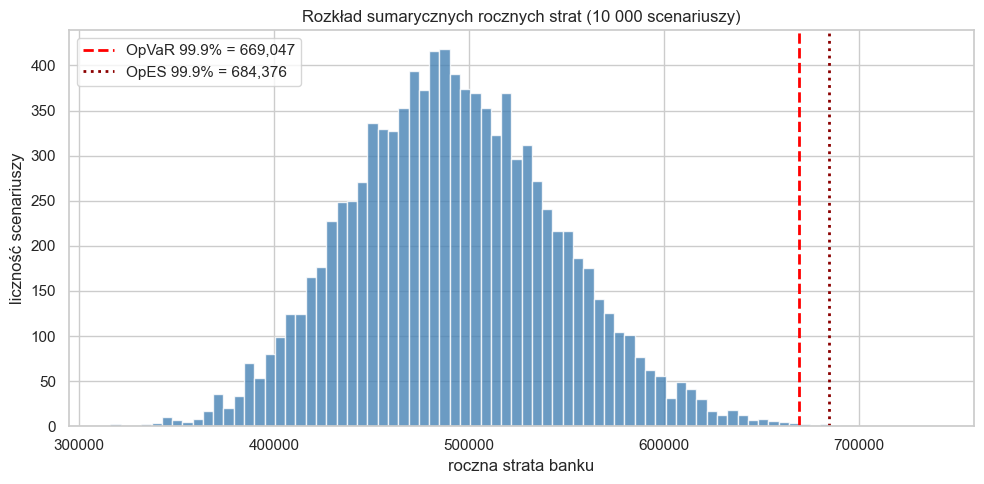

In [12]:
# Histogram sumarycznych strat z zaznaczonym OpVaR i OpES
plt.figure(figsize=(10, 5))
plt.hist(losses_total, bins=80, color="steelblue", alpha=0.8)
plt.axvline(OpVaR, color="red", linestyle="--", lw=2, label=f"OpVaR 99.9% = {OpVaR:,.0f}")
plt.axvline(OpES, color="darkred", linestyle=":", lw=2, label=f"OpES 99.9% = {OpES:,.0f}")
plt.xlabel("roczna strata banku"); plt.ylabel("liczność scenariuszy")
plt.title("Rozkład sumarycznych rocznych strat (10 000 scenariuszy)")
plt.legend()
plt.tight_layout(); plt.show()


## Podsumowanie

In [13]:
summary = pd.DataFrame([
    {
        "linia": L,
        "rozkład częstości": f"{frequency_dist[L][0]}",
        "rozkład dotkliwości": f"{severity_dist[L][0]}",
    }
    for L in LINES
]).set_index("linia")
print(summary)
print(f"\nOpVaR 99.9% = {OpVaR:,.2f}")
print(f"OpES  99.9% = {OpES:,.2f}")


            rozkład częstości rozkład dotkliwości
linia                                            
Internal_Fr             binom               expon
External_Fr             binom               expon

OpVaR 99.9% = 669,046.98
OpES  99.9% = 684,375.76
